# GADGET: First Inspection

Every page so far has read gas on a grid. GADGET does not have one: the gas is **particles**, and
so are the dark matter, the stars and the black holes. This page shows what changes, and what
does not.

The run is a cosmological box at redshift 1.9 with about 12 million particles.

!!! note "You can download this snapshot"
    It is the `GadgetDiskGalaxy` sample from the yt project:

    ```bash
    curl -O https://yt-project.org/data/GadgetDiskGalaxy.tar.gz
    tar xzf GadgetDiskGalaxy.tar.gz
    ```


## 1. What is in the file?


In [1]:
using Mera, CairoMakie

path = "/Volumes/FASTStorage/Simulations/Mera-Tests/GADGET/gadget_diskgalaxy/GadgetDiskGalaxy"
info = getinfo(200, path);



*__   __ _______ ______   _______ 


|  |_|  |       |    _ | |   _   |
|       |    ___|   | || |  |_|  |
|       |   |___|   |_||_|       |
|       |    ___|    __  |       |
| ||_|| |   |___|   |  | |   _   |
|_|   |_|_______|___|  |_|__| |__|
Mera v2.0.0-DEV | Julia 1.12.7 | 8 threads

[Mera]: this snapshot records no unit attributes; using GADGET's defaults (1 kpc/h, 1e10 Msol/h, 1 km/s). Override with unit_length=, unit_density= or unit_velocity= if your run used others.


[Mera]: 2026-09-15T22:02:04.141

Code: GADGET
output: 200

  time: 0.34483  redshift: 1.9
boxlen = 64000.0
particles: 4334546 gas, 4786616 halo/DM, 2333848 disk, 450921 stars, 1149 bndry/BH  (total 11907080)
group catalogue: none found  (halo membership via halo= unavailable)
-------------------------------------------------------
[Mera]: composition not recorded by this format; using X = 0.76, mu = 1.32 (RAMSES convention) for :nH and :T. Change with setcomposition!(info; X_frac=…, mu=…).

A census of the whole snapshot in one call, before loading anything yourself:


In [2]:
ql = quicklook(200; path=path);


[Mera]: quicklook output 200, reading particles: 2026-09-15T22:02:19.751



┌─ Mera quicklook ── output 200 (GADGET) ───────────────


│ box        : 31530.0 kpc      levels 1–1  (finest 1.576e7 pc)
│ grid       : ndim 3 · ncpu 1 · nvarh 0
│ time       : 3510.0 Myr   z = 1.9
│ particles  : 7120468 total  —  stars 2333848 · DM 4786616 · sinks 4
│ star mass  : 2.887e16 M⊙        DM mass : 1.079e14 M⊙
│ current SFR: — (10 Myr) · — (100 Myr) M⊙/yr
└─ 11.99 s ──────────────────────────────────
[Mera]: quicklook output 200 finished: 2026-09-15T22:02:31.740



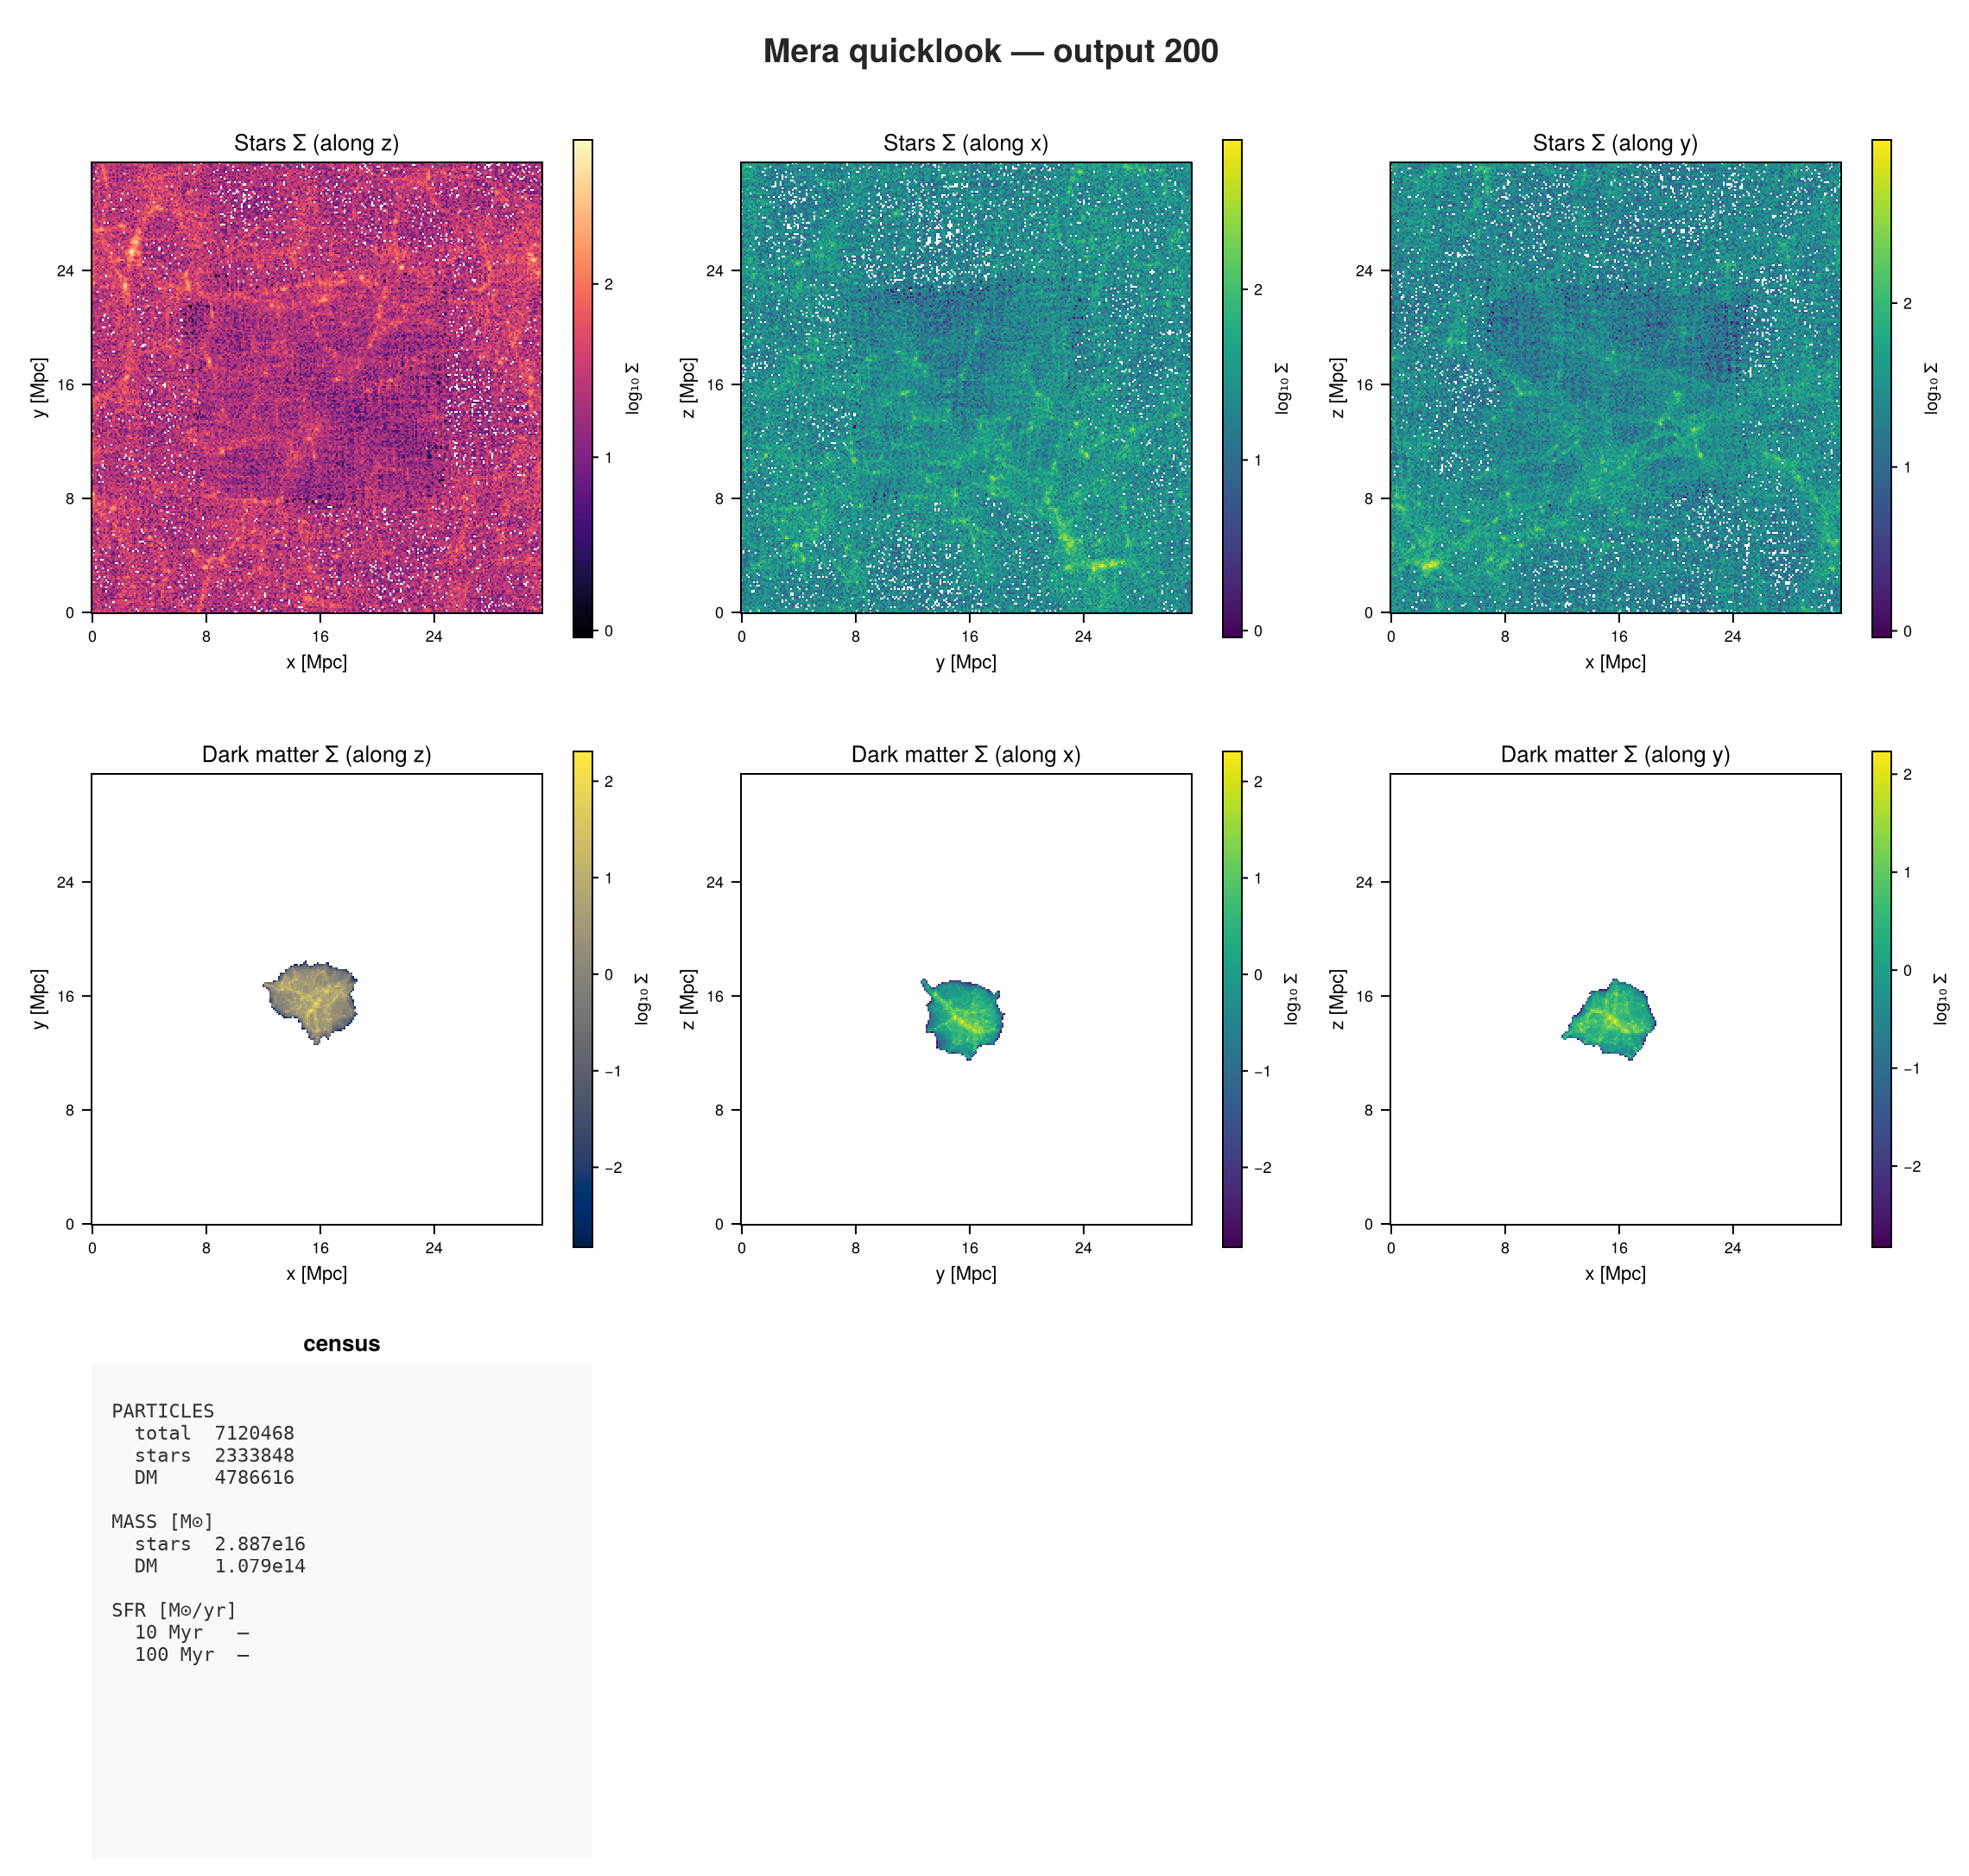

In [3]:
quicklookplot(ql)


Two notices on load, and both are worth reading.

This snapshot records **no unit attributes**, so Mera falls back to GADGET's own documented
defaults: 1 kpc/h, 10¹⁰ M⊙/h, 1 km/s. It also records no gas composition, so `:nH` and `:T` use
the RAMSES convention. Neither is a guess Mera makes quietly; both are stated, and both can be
overridden with keywords or `setcomposition!`.

The run is cosmological, so positions and densities are comoving. Mera folds the expansion factor
and *h* into the unit system, so what you read back is physical.


In [4]:
info.aexp, 1/info.aexp - 1, iscosmological(info)     # scale factor, redshift


(0.3448279989668472, 1.8999965286929705, true)

In [5]:
info.boxlen * info.scale.Mpc                          # physical box size


31.527135612277586

## 2. There is no `gethydro` here

Ask what this code offers, rather than assuming:


In [6]:
capabilities(info)


4-element Vector{Symbol}:
 :info
 :particles
 :groups
 :logs

`:hydro` is absent, and that is correct: **GADGET has no grid**. Gas lives in the particle file
as `PartType0`, so it loads with `getparticles`. Calling `gethydro` would fail with a message
saying exactly that, instead of returning something wrong.

`:groups` and `:logs` are there because SUBFIND catalogues and run-time logs can be read too.


## 3. Load the particles

A snapshot holds several particle families at once. `families=` reads only the ones you want,
which matters when the file has 12 million rows.


In [7]:
gas = getparticles(info; families=[0]);      # PartType0, the gas


[Mera]: GADGET

 gas cells = 4334546, families 0  (x,y,z,vx,vy,vz,mass,id,family,rho,u,ne,sfr,nh,volume)


In [8]:
gas.data


Table with 4334546 rows, 15 columns:
Columns:
#   colname  type
────────────────────
1   x        Float64
2   y        Float64
3   z        Float64
4   vx       Float64
5   vy       Float64
6   vz       Float64
7   mass     Float64
8   id       Int64
9   family   Int32
10  rho      Float64
11  u        Float64
12  ne       Float64
13  sfr      Float64
14  nh       Float64
15  volume   Float64

The table looks different from a grid one. There is **no `level`, `cx`, `cy`, `cz`**: a particle
has no grid address. Instead `:x, :y, :z` are ordinary positions, and `:mass` is per particle.

After that the gas columns are familiar: density, internal energy, electron abundance, star
formation rate. `:volume` is derived as mass over density, which is what lets Mera treat these
as cells with an extent rather than as points.


In [9]:
using StatsBase
countmap(getvar(getparticles(info; verbose=false), :family))   # every family in the file


Dict{Float64, Int64} with 5 entries:
  0.0 => 4334546
  4.0 => 450921
  5.0 => 1149
  2.0 => 2333848
  1.0 => 4786616

Family 0 is gas, 1 is dark matter, 2 the disk component, 4 stars and 5 black holes.


## 4. Physical quantities


In [10]:
msum(gas, :Msol)                    # gas mass


1.9538209622766027e13

In [11]:
extrema(getvar(gas, :rho, :nH))     # hydrogen number density, cm^-3


(1.8817874399131718e-7, 1901.5789627423692)

From 10⁻⁷ to about 10³ per cubic centimetre: void gas at one end, star-forming gas at the other,
which is the range a cosmological box should span.


In [12]:
stars = getparticles(info; families=[4]);
msum(stars, :Msol)


[Mera]: GADGET

 particles = 450921, families 4  (x,y,z,vx,vy,vz,mass,id,family)


1.7674862254989448e12

## 5. A projection

The same call as on every grid code. For particles Mera deposits each one, and because the gas
carries `:volume` it can be smeared over its own size rather than dropped on a single pixel.


In [13]:
proj = projection(gas, :sd, :Msol_pc2, direction=:z, res=256);
size(proj.maps[:sd])


[Mera]: 2026-09-15T22:02:51.238



domain:
xmin::xmax: 0.0 :: 1.0  	==> 0.0 [Mpc] :: 31.527 [Mpc]
ymin::ymax: 0.0 :: 1.0  	==> 0.0 [Mpc] :: 31.527 [Mpc]
zmin::zmax: 0.0 :: 1.0  	==> 0.0 [Mpc] :: 31.527 [Mpc]

Effective resolution: 256^2
Pixel size: 123.153 [kpc]
Simulation min.: 15.764 [Mpc]



(256, 256)

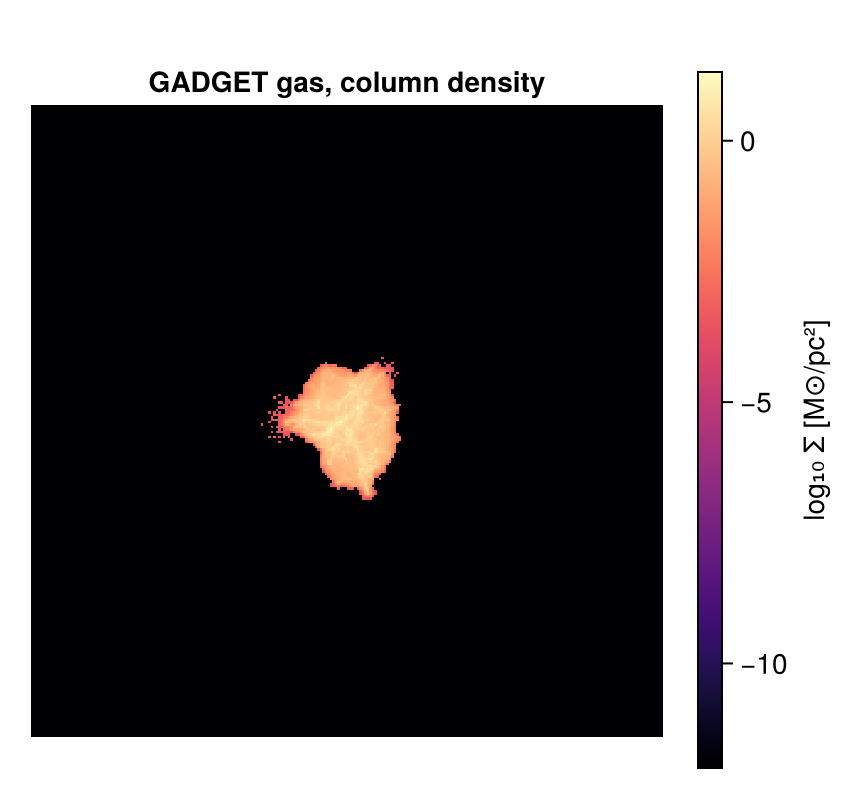

In [14]:
fig = Figure(size=(430, 400))
ax  = Axis(fig[1,1]; title="GADGET gas, column density", aspect=DataAspect())
hidedecorations!(ax)
hm = heatmap!(ax, log10.(proj.maps[:sd]' .+ 1e-12); colormap=:magma)
Colorbar(fig[1,2], hm, label="log₁₀ Σ [M⊙/pc²]")
fig


## Where to go next

The data model changed, the calls did not. `getparticles` instead of `gethydro`, positions
instead of grid addresses, and everything after that is the same: `getvar`, `projection`,
`msum`, sub-regions, profiles and movies.

For weighting choices when projecting particle data, and the difference between `:mass`, `:sph`
and `:voronoi`, see the GADGET and AREPO reader pages.
